In [60]:
import pandas as pd
import os
import numpy as np
def processMain(N):
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_Strat4_15_N"+str(N)+"_1000_")]
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A2_1_15_N"+str(N)+"_")]
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        df = pd.read_csv(''+filename, sep=';', names=['iiter','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K','total_SAA','calls_SAA'], header=None)
        # Use the one below for Iter collection
        # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        df['Ins'] = df['Ins'].astype(int)
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output
N = 40
df_A2_1 = processMain(N)
df_A2_1
# df_A2_1.to_csv("N"+str(N)+"_15_main_A2_1_df.csv")

#<5min

# ins = [1, 2, 5, 6, 7, 8, 9, 10, 11, 12]#N30
# ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13] #N40: 1 3 5 6 7 9 10 11 12 13 xxx
# ins = [2, 6, 7, 10, 13, 14, 15, 16, 17, 21]#N50: 2 6 7 10 13 14 15 16 17 21 xxx

#5-60min
# ins = [4, 20, 83, 89, 107, 166, 172, 174, 200, 241]#N30: 4 20 83 89 107 166 172 174 200 241 xxx
# ins = [4, 8, 16, 20, 27, 28, 33, 36, 37, 48]#N40: 4 8 16 20 27 28 33 36 37 48 xxx
# ins = [18, 26, 30, 46, 73, 93, 98, 110, 113, 122]#N50: 18 26 30 46 73 93 98 110 113 122 xxx

#>60min
# ins = [3, 35, 36, 37, 52, 63, 64, 150, 282, 319]#N30: 3 35 36 37 52 63 64 150 282 319 xxx
ins = [2, 14, 18, 22, 24, 38, 39, 40, 56, 76] #N40: 2 14 18 22 24 38 39 40 56 76 xxx
# ins = [1, 3, 4, 5, 8, 9, 11, 12, 19, 20] #N50: 1 3 4 5 8 9 11 12 19 20 xxx

df_filtered = df_A2_1[df_A2_1['Ins'].isin(ins)]
df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100
print("Average Sol Time ", df_filtered['total_time'].mean())
print("Average |K| ", df_filtered['K'].mean())
print("Average Opt Gap ", df_filtered["OptGap"].mean())
print("Average t_SAA ", df_filtered["total_SAA"].mean())
print("Number of solved ins ", len(df_filtered))
df_A2_1[df_A2_1['Ins'].isin(ins)]
df_filtered



# df_main_less5 = df_main[df_main.total_time < 300]
# df_main_less1hour = df_main[(df_main.total_time < 3600) & (df_main.total_time >=300)]
# df_main_less1hour
# df_main_less5
# df_main_more1hour = df_main[df_main.total_time > 3600]

# df_main_less1hour.sor
# df_main = df_main.loc[df_main.groupby('Ins')['iiter'].idxmax()]
# myIns_list = df_main[df_main.total_time > 180].Ins
# df_main[df_main.total_time > 180]
# print(np.array(df_main_less1hour.sort_values(['Ins']).Ins))

# Ten_Ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13]
# df_main_less5 = df_main_less5[df_main_less5.Ins.isin(Ten_Ins)]
# df_main_less5#.K.mean()

# df_main_less1hour


Average Sol Time  nan
Average |K|  nan
Average Opt Gap  nan
Average t_SAA  nan
Number of solved ins  0


,iiter,total_time,b,ObjVal,LB,x_sol,Kbar,K,total_SAA,calls_SAA,Ins,OptGap


In [73]:
import pandas as pd
import os
import numpy as np
def processMain(N,ins):
    # output = pd.DataFrame(columns="num")
    # output.columns = 
    # print(os.listdir('./Iter/'))

    
    fileNames = []
    # Iterate through files in the directory
    for i in ins:
        fileNames.append("./Iter/main_Strat4_15_N"+str(N)+"_1000_"+str(i)+".txt")
        # fileNames.append("./Iter/main_A3_0_15_N"+str(N)+"_"+str(i)+".txt")
    print(fileNames)
    # Use the next line for finished ins
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_15_N"+str(N)+"_")]
    # prefixed = [filename for filename in os.listdir() for i in ins  if filename.startswith("main_15_N"+str(N)+"_"+str(i))]
    # print(prefixed)
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in fileNames:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        df = pd.read_csv(''+filename, sep=';', names=['iiter','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K','total_SAA'], header=None)
        # Use the one below for Iter collection
        # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        df['Ins'] = split
        df['Ins'] = df['Ins'].astype(int)
        dfs_list.append(df)
        # print(df)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return output

N =30
# <5min
# ins = [1,2,5,6,7,8,9,10,11,12]#N30
# ins = [1,3,5,6,7,9,10,11,12,13]#N40
# ins = [2,6,7,10,13,14,15,16,17,21]#N50

# 5-60min
# ins = [4,20,83,89,107,166,172,174,200,241]#N30
# ins = [4,8,16,20,27,28,33,36,37,48]#N40
# ins = [18,26,30,46,73,93,98,110,113]#N50

# >60min
ins = [3,35,36,37,52,63,64,150,282,319] #N30
# ins = [2,14,18,22,24,38,39,40,56,76] #N40
# ins = [1,3,4,5,8,9,11,12,19,20] #N50

df_main = processMain(N,ins)
df_filtered = df_main.groupby('Ins').apply(
    lambda group: group[(group['iiter'] == group['iiter'].max()) & (group['total_time'] == group['total_time'].max())])
df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100

# print(df_filtered["OptGap"].mean())
# print(df_main_filtered['K'].mean())
print("Average iter ", df_filtered['iiter'].mean()+1)
print("Average |K| ", df_filtered['K'].mean())
print("Average Opt Gap ", df_filtered["OptGap"].mean())
print("Average t_SAA ", df_filtered["total_SAA"].mean())
print("num ins solved ", len(df_filtered))
df_filtered
# df_main.to_csv("N"+str(N)+"_15_main_df.csv")
# df_main_less5 = df_main[df_main.total_time < 300]
# df_main_less1hour = df_main[(df_main.total_time < 3600) & (df_main.total_time >=300)]
# df_main_less1hour
# df_main_less5
# df_main_more1hour = df_main[df_main.total_time > 3600]

# df_main_less1hour.sor
# df_main = df_main.loc[df_main.groupby('Ins')['iiter'].idxmax()]
# myIns_list = df_main[df_main.total_time > 180].Ins
# df_main[df_main.total_time > 180]
# print(np.array(df_main_less1hour.sort_values(['Ins']).Ins))

# Ten_Ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13]
# df_main_less5 = df_main_less5[df_main_less5.Ins.isin(Ten_Ins)]
# df_main_less5#.K.mean()

# df_main_less1hour


['./Iter/main_Strat4_15_N30_1000_3.txt', './Iter/main_Strat4_15_N30_1000_35.txt', './Iter/main_Strat4_15_N30_1000_36.txt', './Iter/main_Strat4_15_N30_1000_37.txt', './Iter/main_Strat4_15_N30_1000_52.txt', './Iter/main_Strat4_15_N30_1000_63.txt', './Iter/main_Strat4_15_N30_1000_64.txt', './Iter/main_Strat4_15_N30_1000_150.txt', './Iter/main_Strat4_15_N30_1000_282.txt', './Iter/main_Strat4_15_N30_1000_319.txt']
Average iter  24.3
Average |K|  2203.4
Average Opt Gap  15.22072440350849
Average t_SAA  2771.9807487010958
num ins solved  10


,,iiter,total_time,b,ObjVal,LB,x_sol,Kbar,K,total_SAA,Ins,OptGap
Ins,,,,,,,,,,,,
3,25,26,2862.456361,10,257.273685,223.382946,[ 1 2 3 29 30 43 69 88 91 110],1324,2200,2552.301237,3,13.173030
35,48,23,2433.127460,10,166.653553,119.278397,[ 1 7 16 17 25 69 86 106 131 136],1646,2256,2236.835326,35,28.427331
36,70,22,3403.986907,10,221.941349,166.210537,[ 2 11 31 32 34 43 44 102 121 132],1752,2761,3074.379635,36,25.110603
37,87,17,2590.723446,10,325.439545,260.399567,[ 1 63 75 86 93 95 111 121 130 145],1068,1870,2438.348605,37,19.985272
52,108,21,3048.007670,10,200.187567,191.926227,[ 1 2 9 15 27 37 42 59 75 84],600,1516,2892.340830,52,4.126800
63,131,23,3581.912946,10,314.492060,299.201272,[ 0 1 24 26 46 52 66 74 98 105],980,2261,3342.848676,63,4.862059
64,155,24,3130.263376,10,449.328887,427.334493,[ 1 16 19 24 36 60 61 62 63 96],2192,2192,2920.182280,64,4.894943
150,177,22,3246.410519,10,257.761343,221.035576,[ 1 22 31 32 45 60 71 97 103 109],1394,2579,3042.072534,150,14.247973
282,206,29,3281.738214,10,266.431990,244.211956,[ 9 17 23 28 39 45 77 80 105 114],852,2092,2989.149668,282,8.339852


In [ ]:
    
def processLazy(EXP, N):
    prefixed = [filename for filename in os.listdir('./') if filename.startswith("lazyDelay_N"+str(N)+"_")]
    dfs_list = []
    for filename in prefixed:
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        
        df = pd.read_csv(filename, sep=';', names=['num_cases','total_time','b','ObjVal','z','x_sol'], header=None)
        df['Ins'] = split
        dfs_list.append(df)
        # print(prefixed)
    output = pd.concat(dfs_list, axis=0, ignore_index=True)
    return output


    
EXP = 'main'

# df_lazy = processLazy(EXP, N)
# df_lazy

# df_lazy.total_time.mean()

# print(df_main.total_time.sum()+3600)/10
# df_main
# (df_main.total_time.sum()+3600*2)/10
# (df_lazy.total_time.sum()+3600)/10
# df_lazy
# df_main

In [ ]:
#x-sol verify
#!/usr/bin/env python
# coding: utf-8

# In[1]:

import importlib
import pandas as pd
import networkx as nx;
import pandas as pd;
import gurobipy as gp;
from gurobipy import GRB;
import csv;
import sys;
import numpy as np
import time
import os 

importlib.import_module("functionProcessInputFile")
from functionProcessInputFile import processInputFile

directory = "./"

N = 30 #sys.argv[1]
testSet = "N"+sys.argv[1]
ins = 4#int(sys.argv[2])


#NEED TO PROCESS X-SOL HERE.
Len, origin, destination, edge,d,cL_orig, cU_orig = processInputFile(testSet, ins)

# In[2]:


# networkCSV = 'TestInstances/CSV_TestInstances/N100/' + 'N100_22.csv';
# N = 1000; #sample size
# budget = 5;
# numpy.random.seed(2024);

# networkCSV = './NewCSVFeb24/N10_1.csv'
num_cases = 100000 #3#int(sys.argv[3]) #1000
b = 10
np.random.seed(20242024) #Use a new seed so SAA algs don't see these yet


xMain = []
xLazy = []
xSAA = []
xSAA_AP = []
xSeq = [1,4,7,26,152,91,126,132,159,112]
dir = "./Sep2024_Output/"
for filename in os.listdir(dir):
    if filename.startswith("main_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        print(df)
        xMain = df['x_sol'][0]
        print(filename)
    if filename.startswith("lazyDelay_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['num_cases','total_time','b','ObjVal','z','x_sol'], header=None)
        xLazy = df['x_sol'][0]
    if filename.startswith("SAA_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        xSAA = df['x_sol'][0]
    if filename.startswith("SAA-AP_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
        xSAA_AP = df['x_sol'][0]
    if filename.startswith("SeqSampling_N"+str(N)+"_"+str(ins)+".txt"):
        df = pd.read_csv(dir+filename, sep=';', names=['numcases','total_time','b','ObjVal','x_sol','para','optgap','ciRight'], header=None)
        xSeq = df['x_sol'][0]
print("xMain ",xMain)
print("xLazy ",xLazy)
print("xSeq ", xSeq)
print("xSAA ", xSAA)
print("xSAA_AP ", xSAA_AP)

# prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_N"+str(N)+"_")]
# In[3]:


# Reading network file
# with open(networkCSV, newline='') as f:
#     reader = csv.reader(f);
#     row1 = next(reader);
#     Len = int(row1[0]);
#     row2 = next(reader);
#     origin = int(row2[0]);
#     row3 = next(reader);
#     destination = int(row3[0]);
    
G = nx.DiGraph();
# data = pd.read_csv(networkCSV, skiprows=4, header=None, sep='\s+');
# n_edge = len(data.index);

for i in range(Len): 
    # G.add_edge(data.iat[i,0], data.iat[i,1], costLB = data.iat[i,2], 
    #         costUB = data.iat[i,3], interEffect = data.iat[i,4], tempCost = 0);
    G.add_edge(edge[i][0], edge[i][1], costLB = cL_orig[i], 
            costUB = cU_orig[i], interEffect = d[i], tempCost = 0);


# In[7]:


print("Len = ", Len);
print("origin = ", origin);
print("destination = ", destination);
# print("G.nodes = ", G.nodes)
# print("G.edges = ", G.edges)
# for e in G.edges:
#     print(e)
#     print(G.edges[e])


# In[5]:


scens = [];

for k in range(num_cases):
    scen = {};
    for e in G.edges:
        scen[e] = np.random.uniform(G.edges[e]['costLB'],G.edges[e]['costUB']);
    scens.append(scen);

ObjMain = -1
ObjLazy = -1
ObjSAA = -1
ObjSAA_AP = -1
ObjSeq = -1
for x in [xMain, xLazy, xSAA, xSAA_AP]:
    xvals = [] #model.cbGetSolution(model._x)
    # print(len(edge))
    # print("x ", x)
    string_array_cleaned = x.strip("[]")  # Remove brackets
    string_list = string_array_cleaned.split()
    x_int = np.array(list(map(int, string_list)))
    for a in x_int:
        # print(a)
        xvals.append((edge[a][0], edge[a][1]))
    print(xvals)
    # thetavals = model.cbGetSolution(model._theta);
    # xSol = [0, 1, 5, 17, 106, 174, 234, 249, 292, 299]
    SP_costs = []
    for k in range(len(scens)):
        # multi-cut version
        # update edge cost per scenario
        for e in G.edges:
            if e in xvals: #xvals[e] > 1e-5:
                G.edges[e]['tempCost'] = scens[k][e] + G.edges[e]['interEffect'];
            else:
                G.edges[e]['tempCost'] = scens[k][e];
        # obtain the shortest path and its length
        spValue = nx.shortest_path_length(G, source=origin, target=destination, weight='tempCost', method='dijkstra')
        SP_costs.append(spValue)
    
    if x == xMain:
        ObjMain = sum(SP_costs)/num_cases
    if x == xLazy:
        ObjLazy = sum(SP_costs)/num_cases
    if x == xSAA:
        ObjSAA = sum(SP_costs)/num_cases
    if x == xSAA_AP:
        ObjSAA_AP = sum(SP_costs)/num_cases
    if x == xSeq:
        ObjSeq = sum(SP_costs)/num_cases
        
        
print(ObjMain)
print(ObjLazy)
print(ObjSAA)
print(ObjSAA_AP)
print(ObjSeq)
# In[6]:


# print("scens[0] = ", scens[0])


# In[8]:
# print(scens)

# x_sol = np.empty((0), int)
# for e in G.edges:
#     if xvals[e] > 1e-5:
#         edge_index = np.where((edge==e).all(1))[0]
#         print(edge_index)
#         x_sol = np.concatenate((x_sol, edge_index), axis=0)
#         print(x_sol);
#         # print(" ")
# # print(edge)
# total_time = time.time() - start
# print(total_time)
# with open(directory+'Sep2024_Output/SolutionVerification.csv', 'a') as the_file:
#     if ObjMain > 0:
#         the_file.write(str(N)+";"+str(ins)+";"+"xMain;"+xMain+";"+str(num_cases)+";"+str(b)+";"+str(ObjMain)+"\n")
#     if ObjLazy > 0:
#         the_file.write(str(N)+";"+str(ins)+";"+"xLazy;"+xLazy+";"+str(num_cases)+";"+str(b)+";"+str(ObjLazy)+"\n")
#     if ObjSAA > 0:
#         the_file.write(str(N)+";"+str(ins)+";"+"xSAA;"+xSAA+";"+str(num_cases)+";"+str(b)+";"+str(ObjSAA)+"\n")
#     if ObjSAA_AP > 0:
#         the_file.write(str(N)+";"+str(ins)+";"+"xSAA_AP;"+xSAA_AP+";"+str(num_cases)+";"+str(b)+";"+str(ObjSAA_AP)+"\n")
#     if ObjSeq > 0:
#         the_file.write(str(N)+";"+str(ins)+";"+"xSeq;"+xSeq+";"+str(num_cases)+";"+str(b)+";"+str(ObjSeq)+"\n")


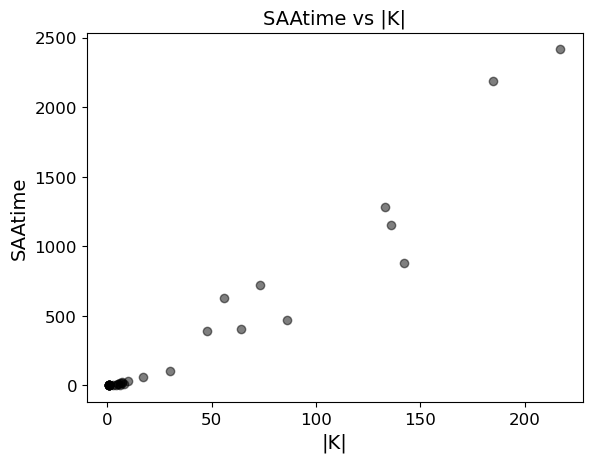

In [119]:
import matplotlib.pyplot as plt
plt.scatter(df_Strat4_1000['K'], df_Strat4_1000['total_SAA'], color='black', marker='o',alpha=0.5)
plt.title('SAAtime vs |K|', fontsize=14)
plt.xlabel('|K|', fontsize=14)
plt.ylabel('SAAtime', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.show()
plt.savefig("mainStrat4_SAAtime_vs_K.png")

In [8]:
df_Strat4_1000

,iiter,total_time,b,ObjVal,x_sol,Ins
0,-1,0.402595,10,330.000000,[ 0 1 2 3 4 5 6 39 75 172],8
1,-1,0.391035,10,330.000000,[ 0 1 2 3 4 5 6 39 75 172],8
2,-1,122.916845,10,371.078125,[ 0 1 2 3 127 134 146 155 161 163],9
3,-1,124.183239,10,371.078125,[ 0 1 2 3 127 134 146 155 161 163],9
4,10,528.015625,[ 2 3 76 78 114 129 131 151 173 185],168.000000,644.110943,70
5,-1,1.318296,10,688.000000,[ 0 1 2 25 38 52 67 70 98 153],10
6,-1,1.199593,10,688.000000,[ 0 1 2 25 38 52 67 70 98 153],10
7,10,112.000000,[ 0 1 2 3 4 5 6 7 8 17],1.000000,0.619513,13
8,10,366.191406,[ 1 3 59 65 83 91 149 162 176 193],24.000000,62.83506,17
9,10,505.000000,[ 0 1 2 3 4 5 6 7 98 116],1.000000,0.67534,28


In [128]:
df_Strat4_5000

,iiter,total_time,b,ObjVal,x_sol,Ins
0,-1,0.387277,10,585.000000,[ 0 1 2 3 4 5 6 7 44 225],8
1,-1,75.194311,10,497.000000,[ 0 2 4 57 165 170 253 272 289 299],2
2,-1,1219.019841,10,509.402508,[ 0 1 40 59 90 205 243 254 277 320],1
3,-1,1206.936786,10,486.491119,[ 0 1 5 17 106 174 234 249 292 299],10
4,-1,233.581529,10,264.234375,[ 0 1 2 3 4 5 118 236 250 292],6
5,-1,0.373258,10,168.000000,[ 0 1 2 3 4 5 6 200 234 260],7


In [131]:
print(len(df_Strat4_5000))
(df_Strat4_5000.total_time.sum()+(10-len(df_Strat4_5000))*3600)/10

6


1713.5493001937866

In [133]:
merged_df = df_Strat4_1000.merge(df_Strat4_5000, on=['Ins'], how='outer')
merged_df = merged_df.merge(df_Strat4_10000, on=['Ins'], how='outer')

In [123]:
merged_df.iloc[:,[4, 10, 15]]

,x_sol_x,x_sol_y,x_sol
0,[ 1 4 77 128 244 270 283 352 427 472],[ 1 4 77 128 244 270 283 352 427 472],NaN
1,[ 2 117 119 137 144 145 148 201 232 495],[ 2 117 119 137 144 145 148 201 232 495],[ 2 117 119 137 144 145 148 201 232 495]
2,[ 0 1 16 42 50 72 167 190 227 299],[ 0 1 16 42 50 72 167 190 227 299],[ 0 1 16 42 50 72 167 190 227 299]
3,[ 0 1 2 22 26 190 228 267 417 436],[ 0 1 2 22 26 190 228 267 417 436],[ 0 1 2 22 26 190 228 267 417 436]
4,[ 0 1 2 10 45 65 247 314 452 461],[ 0 1 2 10 45 65 247 314 452 461],[ 0 1 2 10 45 65 247 314 452 461]
5,[ 0 1 2 3 4 5 6 7 32 156],[ 0 1 2 3 4 5 6 7 32 156],[ 0 1 2 3 4 5 6 7 32 156]
6,[ 0 6 16 28 159 164 273 311 347 420],NaN,[ 0 6 16 28 159 164 273 311 347 420]
